In [1]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.output_parsers import StrOutputParser
import streamlit as st 
import os 
import sys
sys.path.insert(1, r'D:\Notebooks\LLM\env')
from enviorment import load_env
import os 
from langchain_google_genai import ChatGoogleGenerativeAI
load_env()
from langchain_community.tools.tavily_search import TavilySearchResults
from typing import TypedDict,Annotated,Literal
from pydantic import BaseModel, Field
import operator
from langgraph.graph import StateGraph,START, END,MessagesState

from langgraph.types import Command
from langgraph.checkpoint.memory import InMemorySaver
# model=ChatGoogleGenerativeAI(
#     model="gemini-2.5-flash-lite",   # or gemini-2.0-pro, 1.5-pro, etc.
#     temperature=0.2)
#from langchain_core.messages.utils import trim_messages,count_tokens_approximately
#model=ChatOpenAI()
model=ChatOpenAI(model="gpt-4.1-mini")

c:\Users\Dharmendra Vartika\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from langchain_community.document_loaders import PyPDFLoader

In [5]:
docs = (
    PyPDFLoader("book1.pdf").load() +
    PyPDFLoader("book2.pdf").load()
)

In [7]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

In [13]:
spllitter=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)

chunks=spllitter.split_documents(docs)

In [42]:
len(chunks)

4391

In [14]:
from langchain_openai import OpenAIEmbeddings, ChatOpenAI

In [15]:
from langchain_community.vectorstores import FAISS
embeddings = OpenAIEmbeddings(model='text-embedding-3-large')
vector_store = FAISS.from_documents(chunks, embeddings)

In [17]:
retriever=vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 5})

In [18]:
retriever.invoke("what is machine leanring?")

[Document(id='7de4bb55-d2d3-455c-a86f-23bc0f94f69c', metadata={'producer': 'iText 2.1.7 by 1T3XT', 'creator': 'PyPDF', 'creationdate': '', 'moddate': '2019-01-26T22:50:33+16:00', 'enhanced': 'By PDF Enhancer 3.5.6412/Unix', 'spdf': '1127', 'source': 'book2.pdf', 'total_pages': 801, 'page': 114, 'page_label': '115'}, page_content='CHAPTER5.MACHINELEARNINGBASICS\nanoptimizationalgorithm,acostfunction,amodel,andadatasettobuilda\nmachinelearningalgorithm.Finally,insection,wedescribesomeofthe5.11\nfactorsthathavelimitedtheabilityoftraditionalmachinelearningtogeneralize.\nThesechallengeshavemotivatedthedevelopmentofdeeplearningalgorithmsthat\novercometheseobstacles.\n5.1LearningAlgorithms\nAmachinelearningalgorithmisanalgorithmthatisabletolearnfromdata.But\nwhatdowemeanbylearning?Mitchell1997()providesthedeﬁnition“Acomputer\nprogramissaidtolearnfromexperienceEwithrespecttosomeclassoftasksT\nandperformancemeasureP,ifitsperformanceattasksinT,asmeasuredbyP,\nimproveswithexperienceE.”Onecanimagi

In [33]:
class rag(TypedDict):
    question:str
    docs: list[Document]
    response :str

In [34]:
def retrieve_documents(state:rag ) -> rag:
    #from langchain.vectorstores import FAISS
    #from langchain.embeddings.openai import OpenAIEmbeddings

    #embeddings = OpenAIEmbeddings()
    ques=state['question']
    #vectorstore = FAISS.from_documents(docs, embeddings)

    #results = vectorstore.similarity_search(query, k=k)
    state['docs']=retriever.invoke(ques)
    return state

In [35]:
def generate(state:rag) -> rag:
    from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
    from langchain_core.output_parsers import StrOutputParser
    prompt=ChatPromptTemplate.from_messages([
        ("system","You are a helpful assistant that helps people find information."),
        ("user","Use the following pieces of context to answer the question at the end. If you don't know the answer, just say that you don't know, don't try to make up an answer.\n\n{context}\n\nQuestion: {question}\nHelpful Answer:")
    ])
    context=""
    for d in state['docs']:
        context+=d.page_content+"\n"
    inputs={
        "context":context,
        "question":state['question']
    }
    output_parser=StrOutputParser()
    formatted_prompt=prompt.format_prompt(**inputs)
    response=model.invoke(formatted_prompt.to_messages())
    state['response']=output_parser.parse(response)
    return state

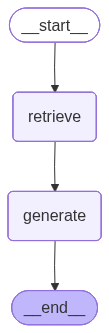

In [36]:
graph=StateGraph(rag)
graph.add_node("retrieve", retrieve_documents)
graph.add_node("generate", generate)
graph.add_edge("retrieve","generate")
graph.add_edge(START,"retrieve")
graph.add_edge("generate",END)
workflow=graph.compile()
workflow

In [40]:
result=workflow.invoke({'question':'what is LLM'})

In [39]:
result['docs']

[Document(id='1683f760-eb75-45be-b9fb-f0acb599e7de', metadata={'producer': 'iText 2.1.7 by 1T3XT', 'creator': 'PyPDF', 'creationdate': '', 'moddate': '2019-01-26T22:50:33+16:00', 'enhanced': 'By PDF Enhancer 3.5.6412/Unix', 'spdf': '1127', 'source': 'book2.pdf', 'total_pages': 801, 'page': 113, 'page_label': '114'}, page_content='challengeofﬁttingthetrainingdatadiﬀersfromthechallengeofﬁndingpatterns\nthatgeneralizetonewdata.Mostmachinelearningalgorithmshavesettings\ncalledhyperparametersthatmustbedeterminedexternaltothelearningalgorithm\nitself;wediscusshowtosettheseusingadditionaldata.Machinelearningis\nessentiallyaformofappliedstatisticswithincreasedemphasisontheuseof\ncomputerstostatisticallyestimatecomplicatedfunctionsandadecreasedemphasis\nonprovingconﬁdenceintervalsaroundthesefunctions;wethereforepresentthe\ntwocentralapproachestostatistics:frequentistestimatorsandBayesianinference.\nMostmachinelearningalgorithmscanbedividedintothecategoriesofsupervised\nlearningandunsupervisedle